data = [
("C1", "Hospital", 5),
("C1", "Park", 3),
("C2", "School", 4),
("C2", "Market", 5),
("C3", "Hospital", 2),
("C3", "Market", 4),
("C4", "Park", 5),
("C4", "School", 3),
("C5", "Hospital", 4),
("C5", "School", 5)
]                                                                                                                                                               a) Construct a bipartite graph using citizens and facilities.
b) Use visit/satisfaction score as edge weight.
c) Visualize the bipartite graph with different colors for citizens and facilities.
d) Create a citizen-facility matrix.
e) Apply KMeans clustering to group citizens based on facility usage.
f) Visualize citizen clusters in the graph.                                                                        

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# -----------------------------
# Data
# -----------------------------
data = [
    ("C1", "Hospital", 5),
    ("C1", "Park", 3),
    ("C2", "School", 4),
    ("C2", "Market", 5),
    ("C3", "Hospital", 2),
    ("C3", "Market", 4),
    ("C4", "Park", 5),
    ("C4", "School", 3),
    ("C5", "Hospital", 4),
    ("C5", "School", 5)
]

df = pd.DataFrame(data, columns=["Citizen", "Facility", "Score"])
print(df)


  Citizen  Facility  Score
0      C1  Hospital      5
1      C1      Park      3
2      C2    School      4
3      C2    Market      5
4      C3  Hospital      2
5      C3    Market      4
6      C4      Park      5
7      C4    School      3
8      C5  Hospital      4
9      C5    School      5


In [18]:
# (a) Construct Bipartite Graph

B = nx.Graph()

citizens = df["Citizen"].unique()
facilities = df["Facility"].unique()

B.add_nodes_from(citizens, bipartite=0)
B.add_nodes_from(facilities, bipartite=1)
print(B.nodes())


['C1', 'C2', 'C3', 'C4', 'C5', 'Hospital', 'Park', 'School', 'Market']


In [5]:
# (b) Add weighted edges

for citizen, facility, score in data:
    B.add_edge(citizen, facility, weight=score)

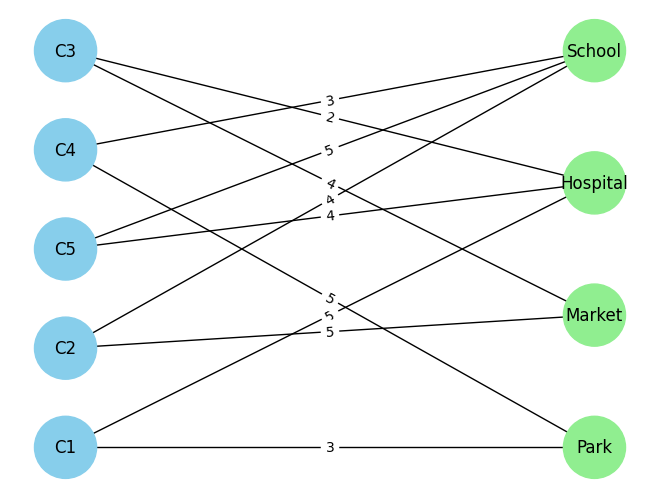

In [9]:
# (c) Visualize Bipartite Graph

pos = nx.bipartite_layout(B, citizens)

colors = []

for node in B.nodes():
    if node in citizens:
        colors.append("skyblue")
    else:
        colors.append("lightgreen")

nx.draw(B, pos,
        with_labels=True,
        node_color=colors,
        node_size=2000)

nx.draw_networkx_edge_labels(
    B,
    pos,
    edge_labels=nx.get_edge_attributes(B, "weight")
)

plt.show()

In [12]:
# (d) Citizen-Facility Matrix

matrix = df.pivot_table(
    index="Citizen",
    columns="Facility",
    values="Score",
    fill_value=0
)

print("Citizen-Facility Matrix")
print(matrix)

Citizen-Facility Matrix
Facility  Hospital  Market  Park  School
Citizen                                 
C1             5.0     0.0   3.0     0.0
C2             0.0     5.0   0.0     4.0
C3             2.0     4.0   0.0     0.0
C4             0.0     0.0   5.0     3.0
C5             4.0     0.0   0.0     5.0


In [15]:
# (e) KMeans Clustering

kmeans = KMeans(n_clusters=2, random_state=42)

matrix["Cluster"] = kmeans.fit_predict(matrix)

print("Citizen Clusters")
print(matrix)


Citizen Clusters
Facility  Hospital  Market  Park  School  Cluster
Citizen                                          
C1             5.0     0.0   3.0     0.0        1
C2             0.0     5.0   0.0     4.0        0
C3             2.0     4.0   0.0     0.0        0
C4             0.0     0.0   5.0     3.0        1
C5             4.0     0.0   0.0     5.0        1


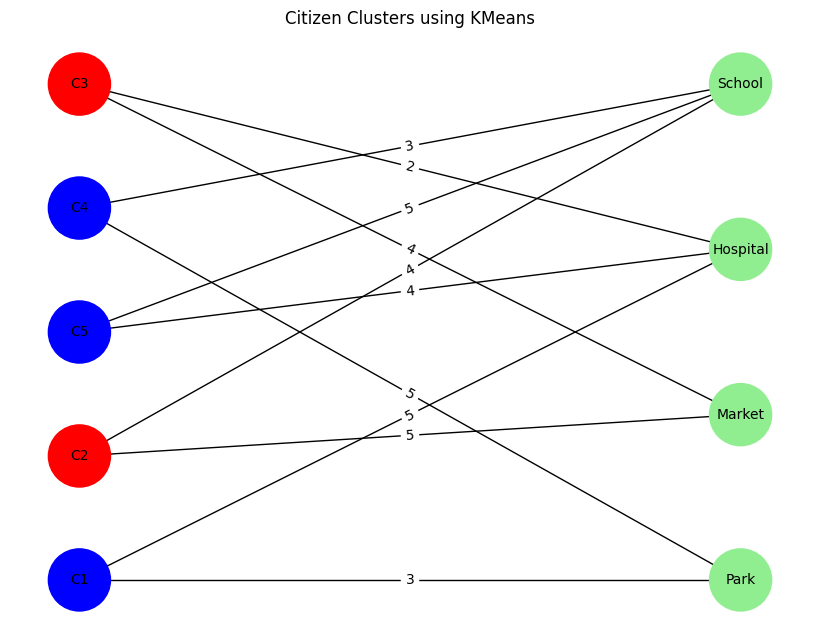

In [16]:
# (f) Visualize Citizen Clusters

cluster_colors = {
    0: "red",
    1: "blue"
}

colors = []

for node in B.nodes():
    if node in citizens:
        cluster = matrix.loc[node, "Cluster"]
        colors.append(cluster_colors[cluster])
    else:
        colors.append("lightgreen")

plt.figure(figsize=(8,6))

nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=2000,
    font_size=10
)

nx.draw_networkx_edge_labels(
    B,
    pos,
    edge_labels=edge_labels
)

plt.title("Citizen Clusters using KMeans")
plt.show()